# Notebook 05 — Explainability
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- **Global explanations** — SHAP summary plots, feature importance
- **Group comparison** — SHAP importance by approved vs. denied group
- **Local explanations** — LIME for individual decisions
- **Counterfactuals** — DiCE: what would change a denial to an approval?
- **Synthesis** — do SHAP, LIME, and DiCE agree on top features?
- **Proxy feature flags** — are geographic features doing hidden work?

> **Capstone connection:** Explainability supports deployment defensibility (question 5). Under ECOA, lenders must provide adverse action notices explaining denials. LIME and DiCE operationalize this.

## 0. Imports & Paths

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import os

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

print('Imports OK')
print(f'BASE_DIR:    {BASE_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')
print(f'TABLES_DIR:  {TABLES_DIR}')

Imports OK
BASE_DIR:    /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code
FIGURES_DIR: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/figures
TABLES_DIR:  /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables


## 0.1 Optional Libraries

`shap`, `lime`, and `dice-ml` are listed in `requirements.txt`. This notebook does not mutate the environment at runtime; if a package is missing, the corresponding section is skipped and the README explains how to install dependencies before execution.

In [2]:
# Import optional libraries without mutating the environment
try:
    import shap
    SHAP_AVAILABLE = True
    print('shap: available')
except ImportError:
    SHAP_AVAILABLE = False
    print('shap: NOT available')

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
    print('lime: available')
except ImportError:
    LIME_AVAILABLE = False
    print('lime: NOT available')

try:
    import dice_ml
    DICE_AVAILABLE = True
    print('dice_ml: available')
except ImportError:
    DICE_AVAILABLE = False
    print('dice_ml: NOT available')

shap: available
lime: available
dice_ml: available


In [3]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
print('Optional-library setup complete.')

Optional-library setup complete.


## 1. Load Artifacts

In [4]:
X_train   = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test    = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train   = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test    = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()
prot_test = pd.read_parquet(os.path.join(BASE_DIR, 'prot_test.parquet'))

model = joblib.load(os.path.join(BASE_DIR, 'best_model.pkl'))
with open(os.path.join(BASE_DIR, 'model_meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(BASE_DIR, 'threshold_meta.json')) as f:
    threshold_meta = json.load(f)

THRESHOLD = float(threshold_meta['global_threshold'])
GROUP_THRESHOLDS = threshold_meta.get('group_thresholds', {})

def apply_threshold_policy(y_prob, groups, global_threshold, group_thresholds=None):
    groups = pd.Series(groups).fillna('Unknown').astype(str)
    thresholds = groups.map(group_thresholds or {}).fillna(global_threshold).astype(float)
    return (np.array(y_prob) >= thresholds.to_numpy()).astype(int)

expected_cols = meta.get('feature_columns', [])
if expected_cols:
    X_test  = X_test[expected_cols]
    X_train = X_train[expected_cols]

y_prob = model.predict_proba(X_test)[:, 1]
if GROUP_THRESHOLDS and 'derived_race' in prot_test.columns:
    y_pred = apply_threshold_policy(y_prob, prot_test['derived_race'], THRESHOLD, GROUP_THRESHOLDS)
else:
    y_pred = (y_prob >= THRESHOLD).astype(int)

print(f'Loaded: {meta["model_name"]} | global threshold={THRESHOLD:.3f}')
print(f'X_test: {X_test.shape}  |  approval rate (actual):    {y_test.mean():.2%}')
print(f'                          approval rate (policy):     {y_pred.mean():.2%}')

Loaded: Gradient Boosting | global threshold=0.729
X_test: (1732355, 21)  |  approval rate (actual):    75.72%
                          approval rate (policy):     87.10%


## 2. SHAP — Global Feature Importance

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive feature contributions.
Uses `LinearExplainer` for Logistic Regression, `TreeExplainer` for Random Forst and Gradient Boosting.

In [5]:
# Sample for SHAP — use aligned X_test
SHAP_SAMPLE = 500
idx_shap = np.random.RandomState(42).choice(len(X_test), SHAP_SAMPLE, replace=False)
X_shap   = X_test.iloc[idx_shap].reset_index(drop=True)
y_shap   = y_test.iloc[idx_shap].reset_index(drop=True)
print(f'SHAP sample: {X_shap.shape}')
print(f'interest_rate in X_shap: {"interest_rate" in X_shap.columns}')

SHAP sample: (500, 21)
interest_rate in X_shap: False


In [6]:
if SHAP_AVAILABLE:
    from sklearn.pipeline import Pipeline

    if isinstance(model, Pipeline):
        clf    = model.named_steps['clf']
        scaler = model.named_steps['scaler']
        X_shap_transformed  = scaler.transform(X_shap)
        X_shap_df  = pd.DataFrame(X_shap_transformed,  columns=X_shap.columns)
        X_train_transformed = scaler.transform(X_train)
        X_train_df = pd.DataFrame(X_train_transformed, columns=X_train.columns)
    else:
        clf        = model
        X_shap_df  = X_shap
        X_train_df = X_train

    try:
        explainer   = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_shap_df)
        shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
        print('Using TreeExplainer')
    except Exception:
        try:
            explainer = shap.LinearExplainer(clf, X_train_df)
            shap_vals = explainer.shap_values(X_shap_df)
            # LinearExplainer on binary classifier returns (n, features, 2)
            # Normalise to (n, features) by taking class 1
            if isinstance(shap_vals, list):
                shap_vals = shap_vals[1]
            elif shap_vals.ndim == 3:
                shap_vals = shap_vals[:, :, 1]
            print('Using LinearExplainer — normalised to class 1')
        except Exception:
            print('Falling back to KernelExplainer (slow)...')
            background = shap.sample(X_train_df, 100, random_state=42)
            explainer  = shap.KernelExplainer(
                lambda x: model.predict_proba(
                    pd.DataFrame(x, columns=X_train.columns))[:, 1],
                background
            )
            shap_vals = explainer.shap_values(X_shap_df, nsamples=100)
            print('Using KernelExplainer')

    print(f'SHAP values shape (after normalisation): {shap_vals.shape}')
else:
    print('SHAP not available.')

Using TreeExplainer
SHAP values shape (after normalisation): (500, 21)


In [7]:
# Normalize shap_vals to 2D (n_samples, n_features) once here
# so all downstream cells work regardless of explainer type
if SHAP_AVAILABLE:
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]
    print(f'shap_vals shape (normalized): {shap_vals.shape}')

shap_vals shape (normalized): (500, 21)


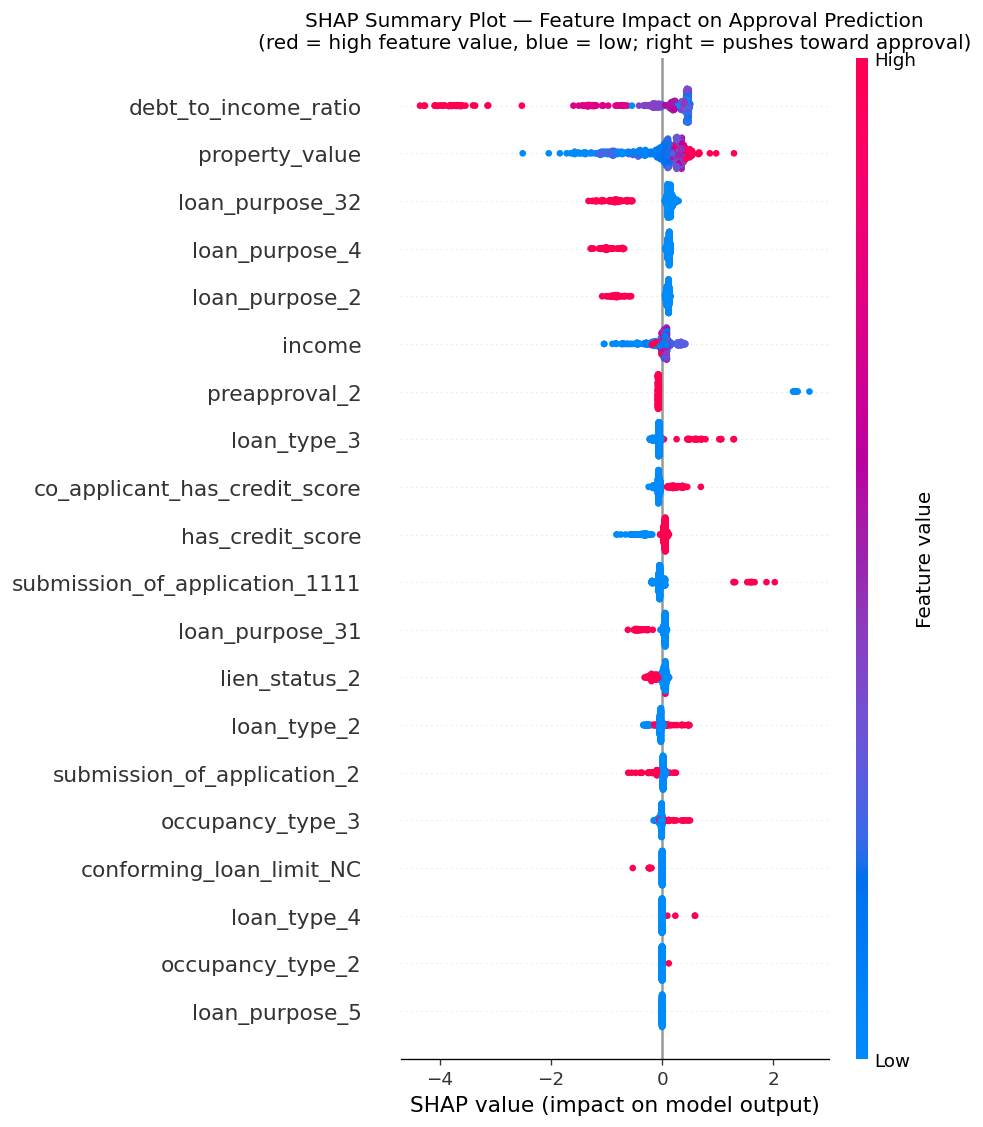

In [8]:
# SHAP Summary Plot — beeswarm
if SHAP_AVAILABLE:
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_vals, X_shap_df,
        plot_type='dot',
        max_display=20,
        show=False
    )
    plt.title('SHAP Summary Plot — Feature Impact on Approval Prediction\n'
              '(red = high feature value, blue = low; right = pushes toward approval)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '05_shap_beeswarm.png'), bbox_inches='tight')
    plt.show()

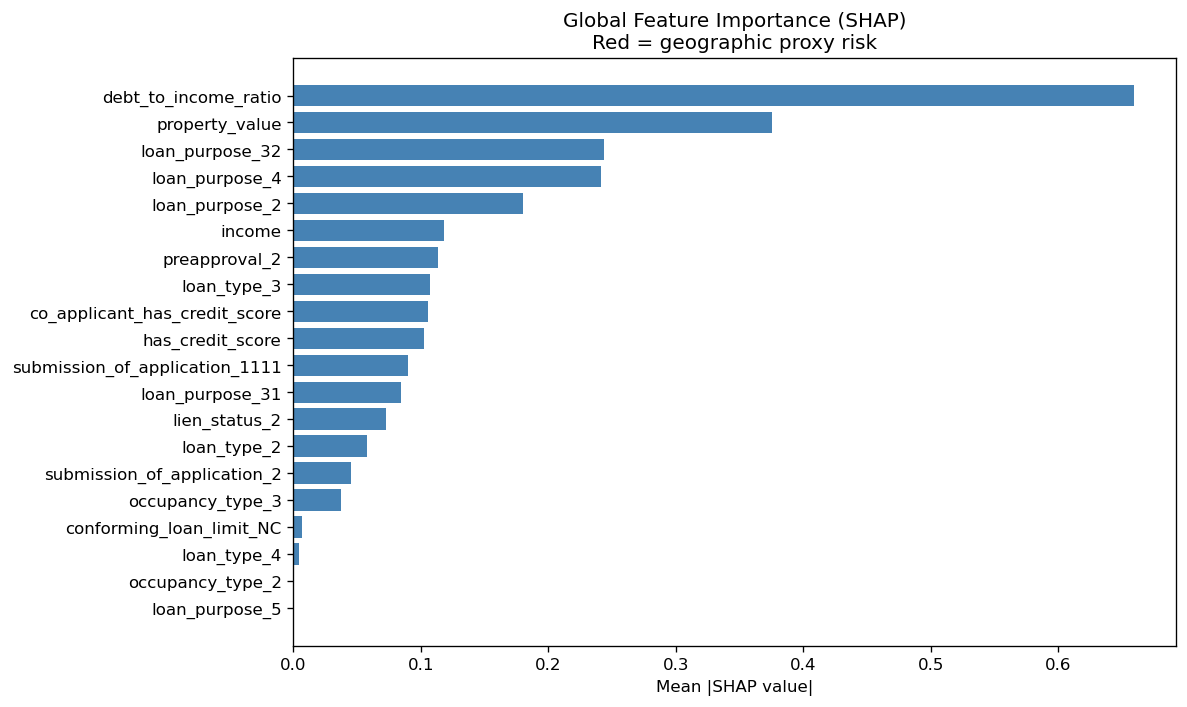

Saved SHAP importance → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/05_shap_importance.csv


In [9]:
# SHAP Bar Plot — mean absolute SHAP values
if SHAP_AVAILABLE:
    # Handle multi-output SHAP values (LinearExplainer returns shape (n, features, 2))
    # We want class 1 (approved) — take the last dimension index 1
    if shap_vals.ndim == 3:
        shap_vals_plot = shap_vals[:, :, 1]   # shape: (n_samples, n_features)
    else:
        shap_vals_plot = shap_vals             # already (n_samples, n_features)

    mean_shap = pd.Series(
        np.abs(shap_vals_plot).mean(axis=0),
        index=X_shap_df.columns
    ).sort_values(ascending=False)

    # Flag geographic proxies
    PROXY_KEYWORDS = ['census_tract', 'tract_', 'county_code', 'msa_md', 'state_code']
    colors = ['crimson' if any(kw in c.lower() for kw in PROXY_KEYWORDS)
              else 'steelblue' for c in mean_shap.head(20).index]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(mean_shap.head(20).index, mean_shap.head(20).values, color=colors)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Global Feature Importance (SHAP)\nRed = geographic proxy risk')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '05_shap_importance.png'))
    plt.show()

    # Save SHAP importance table
    mean_shap.reset_index().rename(
        columns={'index': 'feature', 0: 'mean_abs_shap'}
    ).to_csv(os.path.join(TABLES_DIR, '05_shap_importance.csv'), index=False)
    print(f'Saved SHAP importance → {os.path.join(TABLES_DIR, "05_shap_importance.csv")}')
else:
    mean_shap = pd.Series(dtype=float)

## 3. SHAP — Group Comparison (Approved vs. Denied)

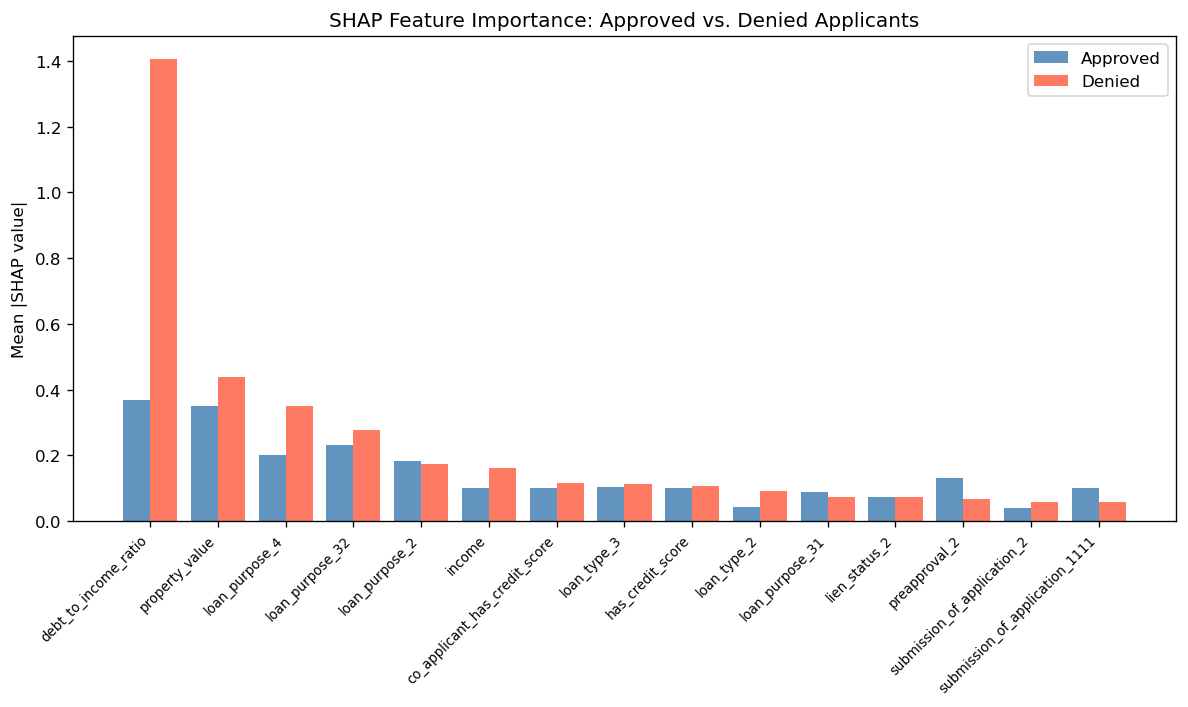

In [10]:
if SHAP_AVAILABLE:
    approved_mask = (y_shap == 1).values
    denied_mask   = (y_shap == 0).values

    # Ensure shap_vals is 2D (n_samples, n_features) before indexing
    sv = shap_vals
    if sv.ndim == 3:
        sv = sv[:, :, 1]   # take class 1 slice

    shap_approved = np.abs(sv[approved_mask]).mean(axis=0)
    shap_denied   = np.abs(sv[denied_mask]).mean(axis=0)

    shap_compare = pd.DataFrame({
        'feature':  X_shap_df.columns,
        'approved': shap_approved,
        'denied':   shap_denied,
    }).sort_values('denied', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    x     = np.arange(len(shap_compare))
    width = 0.40
    ax.bar(x - width/2, shap_compare['approved'], width,
           label='Approved', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, shap_compare['denied'],   width,
           label='Denied',   color='tomato',    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(shap_compare['feature'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean |SHAP value|')
    ax.set_title('SHAP Feature Importance: Approved vs. Denied Applicants')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '05_shap_group_compare.png'))
    plt.show()
else:
    print('SHAP not available — skipping group comparison.')

## 4. SHAP Dependence Plots

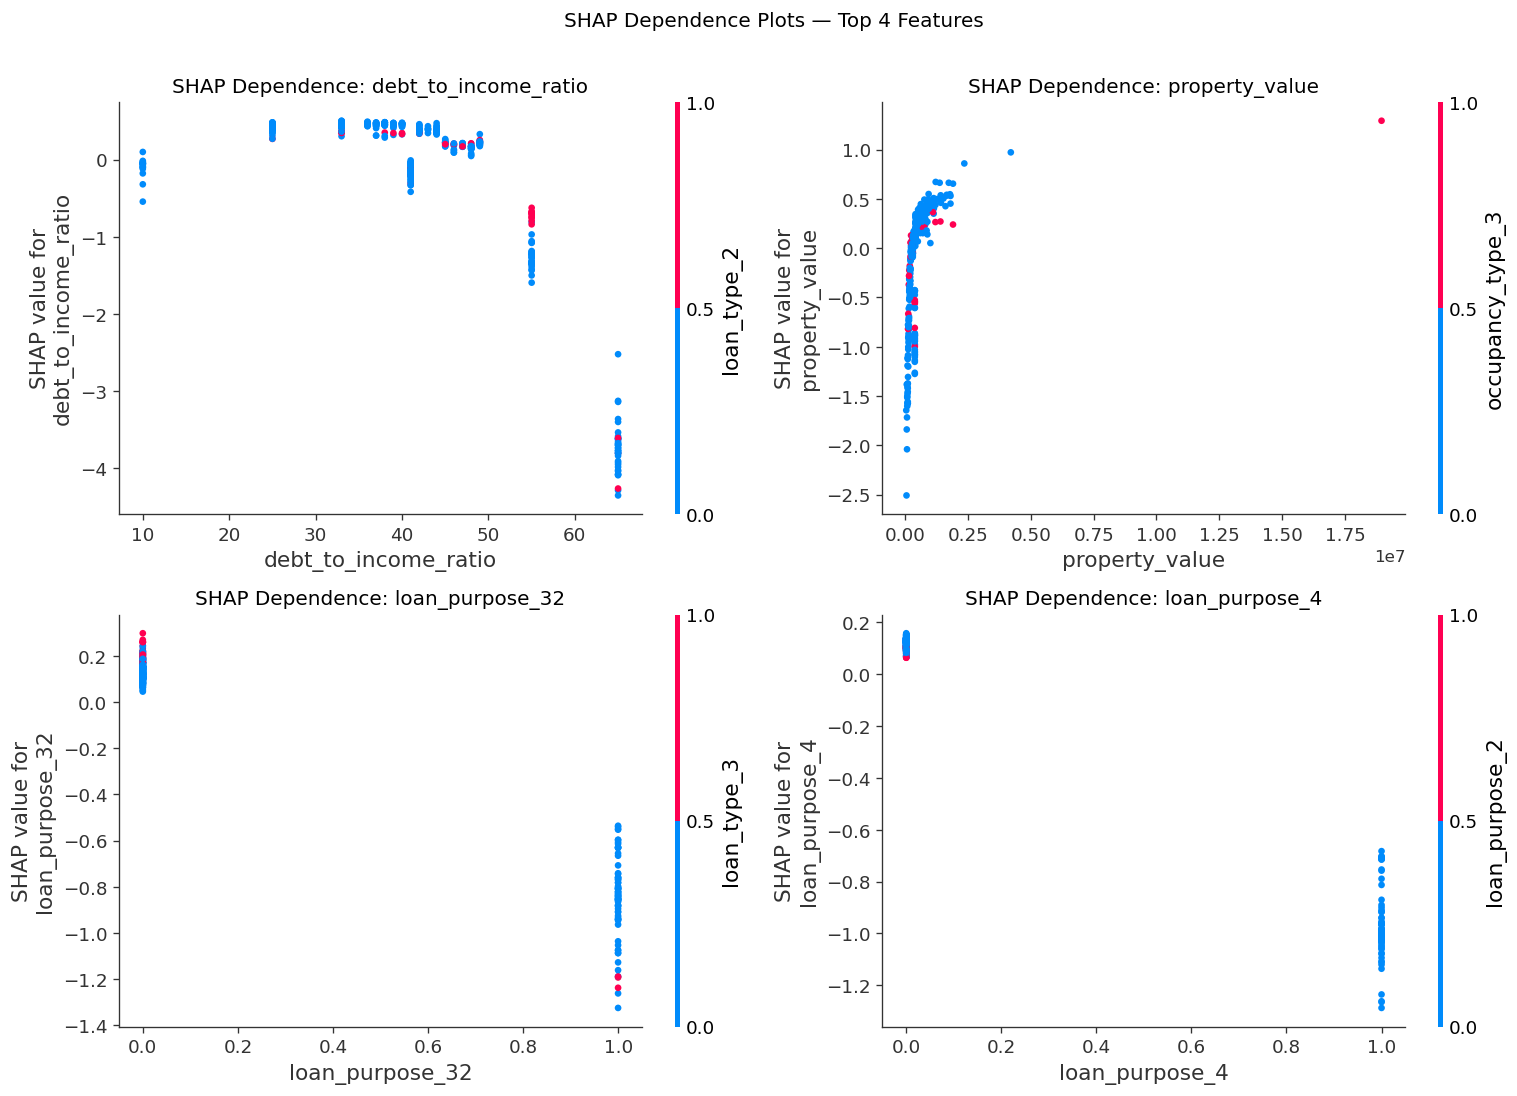

In [11]:
if SHAP_AVAILABLE and len(mean_shap) > 0:
    top_features = mean_shap.head(4).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        feat_idx = list(X_shap_df.columns).index(feat)
        shap.dependence_plot(
            feat_idx,
            shap_vals,
            X_shap_df,
            ax=axes[i],
            show=False
        )
        axes[i].set_title(f'SHAP Dependence: {feat}')

    plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '05_shap_dependence.png'), bbox_inches='tight')
    plt.show()
else:
    print('SHAP not available — skipping dependence plots.')

## 5. LIME — Local Explanations

LIME fits a simple linear model in the neighborhood of a specific instance.
We explain three cases: clear approval, clear denial, and borderline.

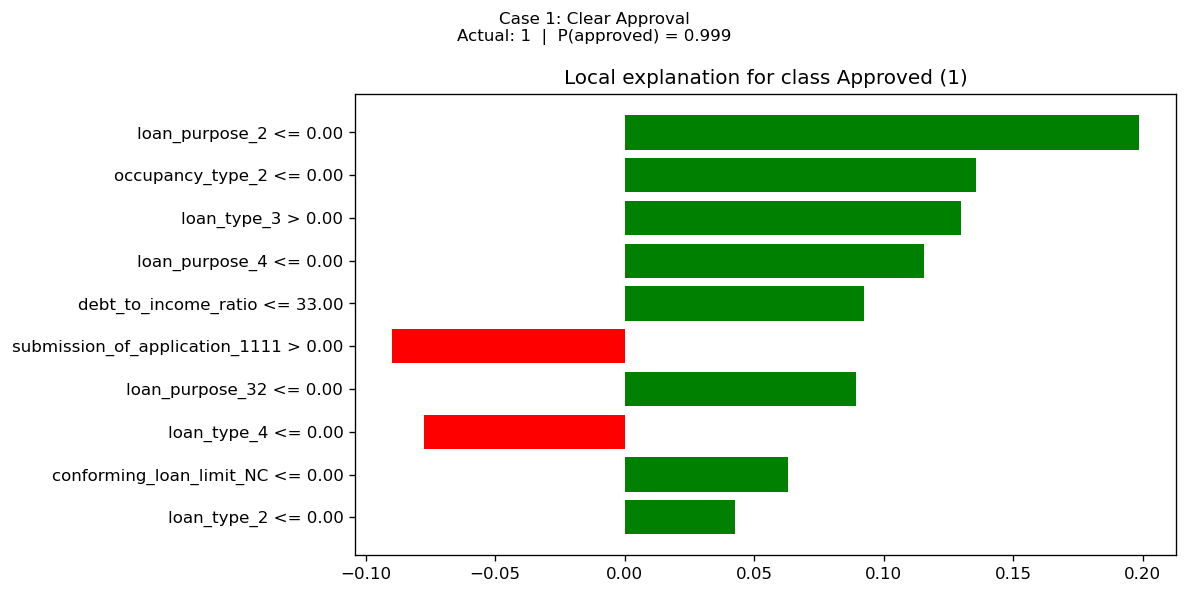

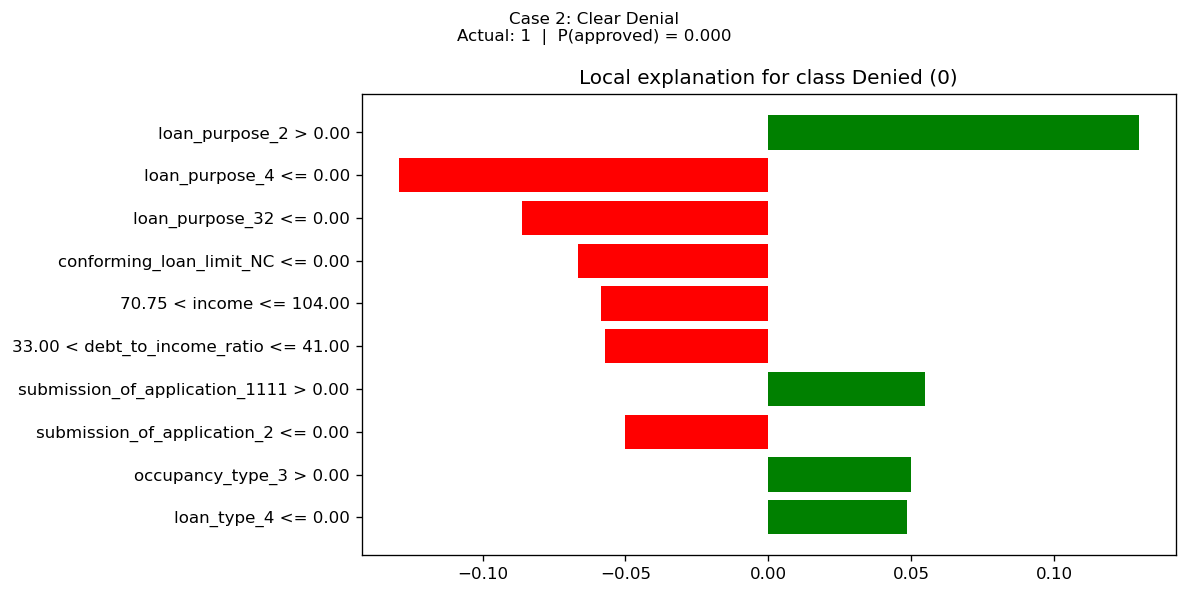

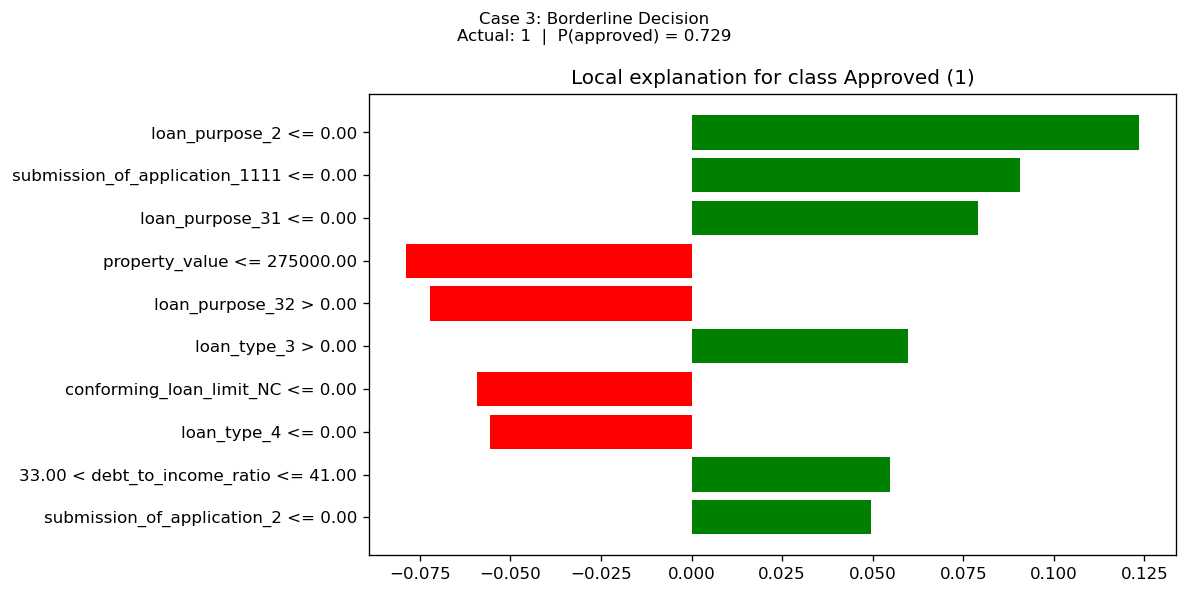

LIME complete.


In [12]:
if LIME_AVAILABLE:
    lime_background = X_train.sample(n=min(1000, len(X_train)), random_state=42).values

    lime_explainer = LimeTabularExplainer(
        training_data=lime_background,
        feature_names=X_train.columns.tolist(),
        class_names=['Denied (0)', 'Approved (1)'],
        mode='classification',
        random_state=42,
    )

    def explain_instance(idx, label, plot_label=1):
        instance = X_test.iloc[idx].values
        prob = model.predict_proba(X_test.iloc[[idx]])[0, 1]
        exp = lime_explainer.explain_instance(
            instance,
            model.predict_proba,
            num_features=10,
            num_samples=300,
            top_labels=2,
        )
        fig = exp.as_pyplot_figure(label=plot_label)
        fig.suptitle(f'{label}\nActual: {int(y_test.iloc[idx])}  |  P(approved) = {prob:.3f}', fontsize=10)
        plt.tight_layout()
        safe_label = label.lower().replace(' ', '_').replace(':', '')
        plt.savefig(os.path.join(FIGURES_DIR, f'05_lime_{safe_label}.png'), bbox_inches='tight')
        plt.show()
        return exp

    policy_denied_idx = np.where(y_pred == 0)[0]
    policy_approved_idx = np.where(y_pred == 1)[0]
    idx_approval = policy_approved_idx[np.argmax(y_prob[policy_approved_idx])]
    idx_denial = policy_denied_idx[np.argmin(y_prob[policy_denied_idx])]
    idx_borderline = np.argmin(np.abs(y_prob - THRESHOLD))

    exp_approval = explain_instance(idx_approval, 'Case 1: Clear Approval', plot_label=1)
    exp_denial = explain_instance(idx_denial, 'Case 2: Clear Denial', plot_label=0)
    exp_borderline = explain_instance(idx_borderline, 'Case 3: Borderline Decision', plot_label=1)
    print('LIME complete.')
else:
    print('LIME not available — skipping.')
    exp_denial = None

## 6. DiCE — Counterfactual Explanations

DiCE answers: **"What would have to change for this denial to become an approval?"**

In [13]:
if DICE_AVAILABLE:
    train_df_dice = X_train.copy()
    train_df_dice['label'] = y_train.values

    bool_cols = train_df_dice.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        train_df_dice[bool_cols] = train_df_dice[bool_cols].astype(int)

    X_test_dice = X_test.copy()
    bool_cols_test = X_test_dice.select_dtypes(include='bool').columns.tolist()
    if bool_cols_test:
        X_test_dice[bool_cols_test] = X_test_dice[bool_cols_test].astype(int)

    continuous_features = [c for c in train_df_dice.columns if c != 'label']
    d = dice_ml.Data(dataframe=train_df_dice, continuous_features=continuous_features, outcome_name='label')
    m = dice_ml.Model(model=model, backend='sklearn')
    exp_dice = dice_ml.Dice(d, m, method='random')
    print('DiCE setup complete.')
else:
    print('DiCE not available — skipping.')

DiCE setup complete.


In [14]:
if DICE_AVAILABLE:
    denied_test_idx = np.where(y_pred == 0)[0]
    if 'derived_race' in prot_test.columns:
        race_groups = prot_test['derived_race'].iloc[denied_test_idx].astype(str).unique()
        selected_indices = []
        for g in race_groups[:3]:
            group_denied = denied_test_idx[(prot_test['derived_race'].iloc[denied_test_idx].astype(str) == g).values]
            if len(group_denied) > 0:
                selected_indices.append(group_denied[0])
    else:
        selected_indices = denied_test_idx[:3]

    cf_results = []
    for i, idx in enumerate(selected_indices[:3], start=1):
        query_instance = X_test_dice.iloc[[idx]]
        race_label = prot_test['derived_race'].iloc[idx] if 'derived_race' in prot_test.columns else f'Case {i}'
        try:
            dice_exp = exp_dice.generate_counterfactuals(query_instance, total_CFs=3, desired_class='opposite', random_seed=42)
            cf_df = dice_exp.cf_examples_list[0].final_cfs_df
            print(f'\n── Counterfactuals for denied applicant (group: {race_label}) ──')
            print(cf_df.to_string())
            cf_df.to_csv(os.path.join(TABLES_DIR, f'05_dice_counterfactual_case_{i}.csv'), index=False)
            cf_results.append({'group': race_label, 'cf_df': cf_df})
        except Exception as e:
            print(f'DiCE failed for index {idx}: {e}')
else:
    print('DiCE not available — skipping.')

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.98s/it]

100%|██████████| 1/1 [00:03<00:00,  3.98s/it]


── Counterfactuals for denied applicant (group: Race Not Available) ──
   income  debt_to_income_ratio  property_value  has_credit_score  co_applicant_has_credit_score  loan_type_2  loan_type_3  loan_type_4  loan_purpose_2  loan_purpose_4  loan_purpose_5  loan_purpose_31  loan_purpose_32  occupancy_type_2  occupancy_type_3  lien_status_2  conforming_loan_limit_NC  conforming_loan_limit_U  preapproval_2  submission_of_application_2  submission_of_application_1111  label
0    49.0                  23.9        255000.0                 1                              0            0            0            0               0               0               0                0                0                 0                 0              0                         0                        0              1                            0                               0      1
1    49.0                  65.0        255000.0                 1                              0            0            0

  0%|          | 0/1 [00:00<?, ?it/s]

...


── Counterfactuals for denied applicant (group: White) ──
   income  debt_to_income_ratio  property_value  has_credit_score  co_applicant_has_credit_score  loan_type_2  loan_type_3  loan_type_4  loan_purpose_2  loan_purpose_4  loan_purpose_5  loan_purpose_31  loan_purpose_32  occupancy_type_2  occupancy_type_3  lien_status_2  conforming_loan_limit_NC  conforming_loan_limit_U  preapproval_2  submission_of_application_2  submission_of_application_1111  label
0    35.0                  17.6        255000.0                 1                              0            0            0            0               0               1               0                0                0                 0                 0              1                         0                        0              1                            0                               0      1
1    35.0                  44.8        255000.0                 1                              0            0            0            0

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.03s/it]

100%|██████████| 1/1 [00:04<00:00,  4.03s/it]


── Counterfactuals for denied applicant (group: Black or African American) ──
   income  debt_to_income_ratio  property_value  has_credit_score  co_applicant_has_credit_score  loan_type_2  loan_type_3  loan_type_4  loan_purpose_2  loan_purpose_4  loan_purpose_5  loan_purpose_31  loan_purpose_32  occupancy_type_2  occupancy_type_3  lien_status_2  conforming_loan_limit_NC  conforming_loan_limit_U  preapproval_2  submission_of_application_2  submission_of_application_1111  label
0    76.0                  65.0        305000.0                 1                              0            1            0            0               0               0               0                0                0                 0                 0              0                         0                        0              0                            0                               0      1
1  9952.4                  65.0        305000.0                 1                              0            1      

## 7. Synthesis — Do SHAP, LIME, and DiCE Agree?

In [15]:
print('── Explainability Synthesis ──')
print()

if SHAP_AVAILABLE and len(mean_shap) > 0:
    top_shap = mean_shap.head(5).index.tolist()
    print(f'SHAP global top 5:  {top_shap}')
else:
    top_shap = []
    print('SHAP: not available')

lime_clean = []
if LIME_AVAILABLE and exp_denial is not None:
    try:
        lime_features = [feat for feat, _ in sorted(
            exp_denial.as_list(label=1), key=lambda x: abs(x[1]), reverse=True
        )[:5]]
        lime_clean = [f.split(' ')[0].split('>')[0].split('<')[0].strip() for f in lime_features]
        print(f'LIME (denial case) top 5: {lime_clean}')
    except Exception:
        print('LIME: explanation not available')
else:
    print('LIME: not available')

if top_shap and lime_clean:
    overlap = set(top_shap[:5]) & set(lime_clean[:5])
    print(f'\nOverlap (SHAP ∩ LIME top 5): {overlap}')
    if len(overlap) >= 3:
        print('✓ Strong agreement — model behavior is consistent globally and locally')
    else:
        print('⚠ Weak agreement — local and global explanations diverge; investigate')

print()
print('Proxy feature flags:')
PROXY_KEYWORDS = ['census_tract', 'tract_', 'county_code', 'msa_md', 'state_code']
if SHAP_AVAILABLE and len(mean_shap) > 0:
    top10 = mean_shap.head(10).index.tolist()
    flagged_proxies = [f for f in top10 if any(kw in f.lower() for kw in PROXY_KEYWORDS)]
    if flagged_proxies:
        print(f'  ⚠ Geographic proxy features in top 10 SHAP: {flagged_proxies}')
        print('    These features may encode race via redlining patterns.')
    else:
        print('  ✓ No geographic proxy features in top 10 SHAP importance')

── Explainability Synthesis ──

SHAP global top 5:  ['debt_to_income_ratio', 'property_value', 'loan_purpose_32', 'loan_purpose_4', 'loan_purpose_2']
LIME (denial case) top 5: ['loan_purpose_2', 'loan_purpose_4', 'loan_purpose_32', 'conforming_loan_limit_NC', '70.75']

Overlap (SHAP ∩ LIME top 5): {'loan_purpose_4', 'loan_purpose_2', 'loan_purpose_32'}
✓ Strong agreement — model behavior is consistent globally and locally

Proxy feature flags:
  ✓ No geographic proxy features in top 10 SHAP importance


In [16]:
# Final synthesis table
synthesis = pd.DataFrame([
    {
        'Method':      'SHAP (global)',
        'Scope':       'All test instances',
        'Use Case':    'Overall feature importance; audit trail',
        'Key Finding': ', '.join(top_shap[:3]) if top_shap else 'Not computed'
    },
    {
        'Method':      'LIME (local)',
        'Scope':       'Single instances',
        'Use Case':    'ECOA adverse action notice; individual explanation',
        'Key Finding': 'See Case 2 (denial) explanation above'
    },
    {
        'Method':      'DiCE (counterfactual)',
        'Scope':       'Denied applicants',
        'Use Case':    'Actionable recourse; what would change the outcome',
        'Key Finding': 'See counterfactual results above'
    },
])

print('── Explainability Methods Summary ──')
print(synthesis.to_string(index=False))

# Save outputs
synthesis_path = os.path.join(TABLES_DIR, '05_explainability_synthesis.csv')
synthesis.to_csv(synthesis_path, index=False)
print(f'\nSaved synthesis → {synthesis_path}')

if SHAP_AVAILABLE and len(mean_shap) > 0:
    shap_path = os.path.join(TABLES_DIR, '05_shap_importance.csv')
    mean_shap.reset_index().rename(
        columns={'index': 'feature', 0: 'mean_abs_shap'}
    ).to_csv(shap_path, index=False)
    print(f'Saved SHAP importance → {shap_path}')

── Explainability Methods Summary ──
               Method              Scope                                           Use Case                                           Key Finding
        SHAP (global) All test instances            Overall feature importance; audit trail debt_to_income_ratio, property_value, loan_purpose_32
         LIME (local)   Single instances ECOA adverse action notice; individual explanation                 See Case 2 (denial) explanation above
DiCE (counterfactual)  Denied applicants Actionable recourse; what would change the outcome                      See counterfactual results above

Saved synthesis → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/05_explainability_synthesis.csv
Saved SHAP importance → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables/05_shap_importance.csv
